# Amplitude sweep — a train of pulses with increasing amplitude

A minimal end-to-end **co-simulation** demo. An on-core `@kernel` fires a train of gate pulses
whose amplitude ramps up step by step; we capture the resulting **DAC waveform** straight off the
Verilated `PulseTableSoc` and plot it.

It uses the same host software as the calibration notebooks — `riscq.lang` compiles the kernel to
C for the RISC-V core, `riscq.run` drives the boot/run protocol, and `riscq.sim` brings up the
cocotb bench — but needs no qubit model: we just look at the raw drive signal the hardware emits.

The first cell Verilates the SoC (~1–2 min the first time; cached afterwards under
`software/build/sim-2q/`).

In [2]:
from pathlib import Path

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import riscq
from riscq import run as rq
from riscq.lang import Array, ParamTable, compile_kernel, kernel
from riscq.map import LEAD, SocMap, SocParams
from riscq.pulses import Pulse, envelopes, units
from riscq.sim import server

SW = Path(riscq.__file__).resolve().parents[1]          # .../software (robust to the notebook cwd)

drv = server.start(SW / 'configs' / 'sim-2q.json', SW / 'build' / 'sim-2q')
m = SocMap(SocParams.from_json(drv.sim.get_params()))
print('cosim up —', m.params.qubit_num, 'cores, DAC sample rate',
      units.sample_rate(m.params) / 1e9, 'GS/s')

cosim up — 2 cores, DAC sample rate 1.6 GS/s


## The kernel

A pulse lives in a `ParamTable`: one RF **channel** (index 0 = this core's gate drive), a carrier
frequency, and a dict of named pulses. `init_pulse_params` loads the table into the hardware pulse
slots; `set_freq` programs the carrier; each loop iteration bumps the amplitude with `set_amp` and
`play`s the pulse `LEAD` batches into the future, then `wait_until` holds the core past the pulse so
the next one lands cleanly after a small `gap`.

`now()`, `play`, `set_amp`, … are firmware intrinsics resolved by name at compile time (hence the
`# noqa: F821`), not Python functions. Amplitudes are passed as integer hardware codes
(`amp_to_code`, full scale `AMP_SCALE = 19896`), so the ramp is just `a0 + i * da`.

In [ ]:
N = 6                                     # pulses in the train
F_DRIVE = 80e6                            # carrier frequency (Hz)
amps = np.linspace(0.15, 0.9, N)          # commanded amplitudes (fraction of full scale)
a0 = units.amp_to_code(amps[0])           # ramp as hardware codes: a0, a0+da, a0+2da, ...
da = units.amp_to_code(amps[1]) - a0


@kernel
def amp_sweep(gate: ParamTable, ts: Array, n: int, a0: int, da: int, gap: int):
    """Fire `n` gate pulses back to back, raising the amplitude by `da` each step."""
    init_pulse_params(gate.pulses)                     # noqa: F821  load the pulse table into HW
    set_freq(gate, gate.freq)                          # noqa: F821  program the carrier
    a = a0
    for i in range(n):
        set_amp(gate, gate["x90"], a)        # noqa: F821  step the amplitude
        t = now() + LEAD                               # noqa: F821  schedule LEAD batches ahead
        ts[i] = t                                       # record the fire time for the host
        play(gate, gate["x90"], t)                     # noqa: F821
        a = a + da
        wait_until(t + gate["x90"].dur + gap)          # noqa: F821  hold past the pulse + gap


# one flat-top gate pulse, reused at every amplitude step
pulse = Pulse(envelopes.cos_edge_square(48, 0.3), freq_hz=F_DRIVE, amp=1.0)
gate = ParamTable(0, F_DRIVE, {"x90": pulse})
prog = compile_kernel(amp_sweep, m, tables=dict(gate=gate), ts=Array(N))

dur = len(pulse.packed_lines(m, "gate"))               # pulse length in batches
print(f'compiled: {N} pulses, {dur} batches ({units.ns(dur, m.params):.0f} ns) each, '
      f'amplitude {amps[0]:.2f} -> {amps[-1]:.2f}')

compiled: 6 pulses, 12 batches (120 ns) each, amplitude 0.15 -> 0.90


## Run it and capture the DAC

The boot protocol is the same one `riscq.run.run` wraps: hold reset, load the image + envelope RAM
+ pulse table, write the loop parameters, then release. We **arm a DAC capture** on core-0's gate
converter *before* releasing reset, run until the kernel reports DONE, read back the recorded fire
times, and fetch the captured samples — an `(n_batches, 16)` array of `int16` DAC codes (16 samples
per batch).

The core issues each pulse as fast as it can execute the loop (a couple of µs apart here), so `gap`
is a *floor* on the spacing, not the actual period — the fire times come back in `ts` so we can
locate each pulse in the capture regardless.

In [5]:
GAP = 8                                   # minimum idle batches between pulses
NBATCH = 2400                             # DAC capture length in batches

rq.reset(drv, m, on=True)                                   # hold the core in reset while loading
rq.load_program(drv, m, 0, prog.image)
rq.check_magic(drv, m, 0, prog)
rq.load_envelopes(drv, m, 0, prog)                          # pulse shape -> envelope RAM
rq.load_tables(drv, m, 0, prog)                             # design-time pulse codes -> .data table
rq.write_params(drv, m, 0, prog, dict(n=N, a0=int(a0), da=int(da), gap=GAP))
rq.park_core(drv, m, 1)                                     # the unused core just self-loops

handle = drv.sim.dac_capture_arm(m.gate_dac(0), NBATCH)     # record core-0's gate DAC
rq.reset(drv, m, on=False)                                  # release: the program runs
rq.poll_done(drv, m, 0, prog, timeout=1_000_000)            # wait for the kernel to finish
ts = [int(t) for t in rq.read_array(drv, m, 0, prog, 'ts')[:N]]   # the N fire times (batches)
rq.reset(drv, m, on=True)
t0, cap = drv.sim.dac_capture_get(handle)                   # (NBATCH, 16) int16 DAC samples

print('fire times (batches):', ts)
print('capture shape:', cap.shape)

fire times (batches): [305, 461, 608, 755, 902, 1049]
capture shape: (2400, 16)


## Visualize

Flatten the capture to a 1-D DAC-sample stream; each pulse `i` occupies DAC samples
`[(ts[i]-t0)*16, (ts[i]-t0+dur)*16)`. Three views:

- **top** — the whole train: six carrier bursts stepping up in amplitude (shaded, coloured by
  amplitude);
- **bottom-left** — the individual pulses aligned at their start, so you see the carrier under the
  flat-top envelope growing step by step;
- **bottom-right** — the peak of each burst versus the commanded amplitude: a straight line, so the
  output scales linearly with the code we programmed.

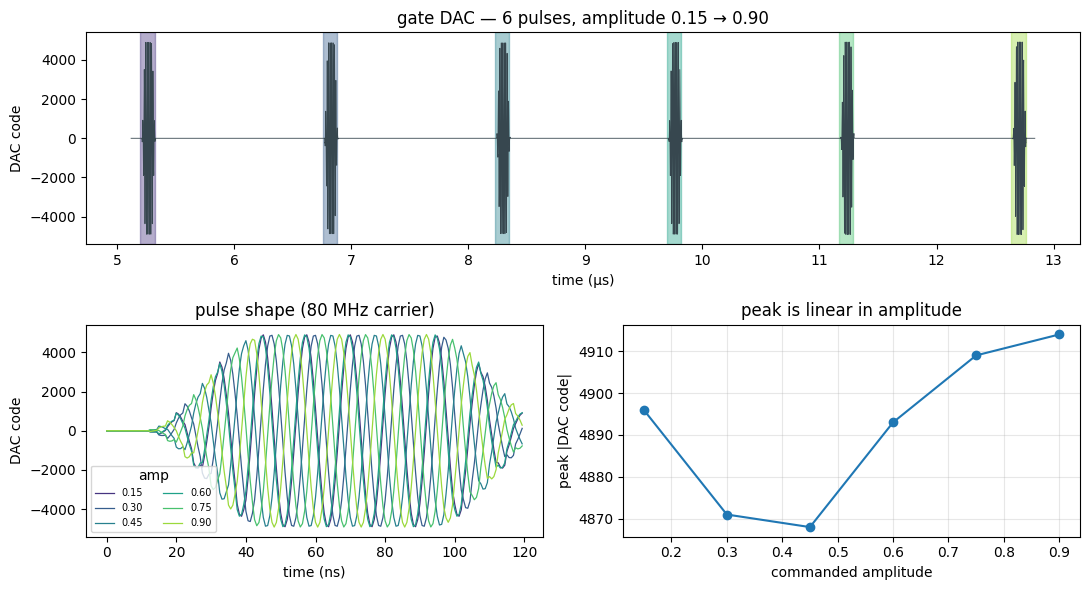

In [6]:
wave = cap.reshape(-1).astype(float)            # 1-D DAC-sample stream (time order)
SPB = cap.shape[1]                              # DAC samples per batch (16)
ns_per_sample = units.ns(1, m.params) / SPB     # 0.625 ns

starts = [(t - t0) * SPB for t in ts]           # first DAC sample of each pulse
span = dur * SPB                                # pulse length in DAC samples
assert starts[-1] + span <= len(wave), 'raise NBATCH: the train ran past the capture'
colors = plt.cm.viridis(np.linspace(0.15, 0.85, N))

fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(2, 2)
ax_train = fig.add_subplot(gs[0, :])
ax_shape = fig.add_subplot(gs[1, 0])
ax_lin = fig.add_subplot(gs[1, 1])

# the whole train
lo, hi = starts[0] - 8 * SPB, starts[-1] + span + 8 * SPB
ax_train.plot(np.arange(lo, hi) * ns_per_sample / 1e3, wave[lo:hi], lw=0.6, color='#37474f')
for a, s, col in zip(amps, starts, colors):
    ax_train.axvspan(s * ns_per_sample / 1e3, (s + span) * ns_per_sample / 1e3, color=col, alpha=0.4)
ax_train.set_xlabel('time (µs)'); ax_train.set_ylabel('DAC code')
ax_train.set_title(f'gate DAC — {N} pulses, amplitude {amps[0]:.2f} → {amps[-1]:.2f}')

# the pulses, aligned at t=0 and coloured by amplitude
for a, s, col in zip(amps, starts, colors):
    ax_shape.plot(np.arange(span) * ns_per_sample, wave[s:s + span], lw=0.9, color=col, label=f'{a:.2f}')
ax_shape.set_xlabel('time (ns)'); ax_shape.set_ylabel('DAC code')
ax_shape.set_title(f'pulse shape ({F_DRIVE / 1e6:.0f} MHz carrier)')
ax_shape.legend(title='amp', fontsize=7, ncol=2)

# peak output vs commanded amplitude
peaks = np.array([np.abs(wave[s:s + span]).max() for s in starts])
ax_lin.plot(amps, peaks, 'o-', color='#1f77b4')
ax_lin.set_xlabel('commanded amplitude'); ax_lin.set_ylabel('peak |DAC code|')
ax_lin.set_title('peak is linear in amplitude'); ax_lin.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Shut the co-sim down

In [5]:
server.stop(drv)
print('cosim stopped')

cosim stopped
